<a href="https://colab.research.google.com/github/DanielG12-Hub/Propagation/blob/main/FWI_test_Forawrd_N_back_prop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Configuración Sísmica Cargada ---
Adquisición 2D: Bilateral | 80 Tiros Totales.
Cable Sísmico: 120 Canales con Offset Máx de 5000.0m.

[CLICK] Ejecutando Forward Modeling en Subsuelo Real...
[CLICK] Ejecutando Forward Modeling en tu Modelo de Gradiente Inicial...
[CLICK] Calculando el Residuo (Resta de Sismogramas)...
[CLICK] Generando el Modelo Actualizado (Backward Modeling / Gradiente FWI)...


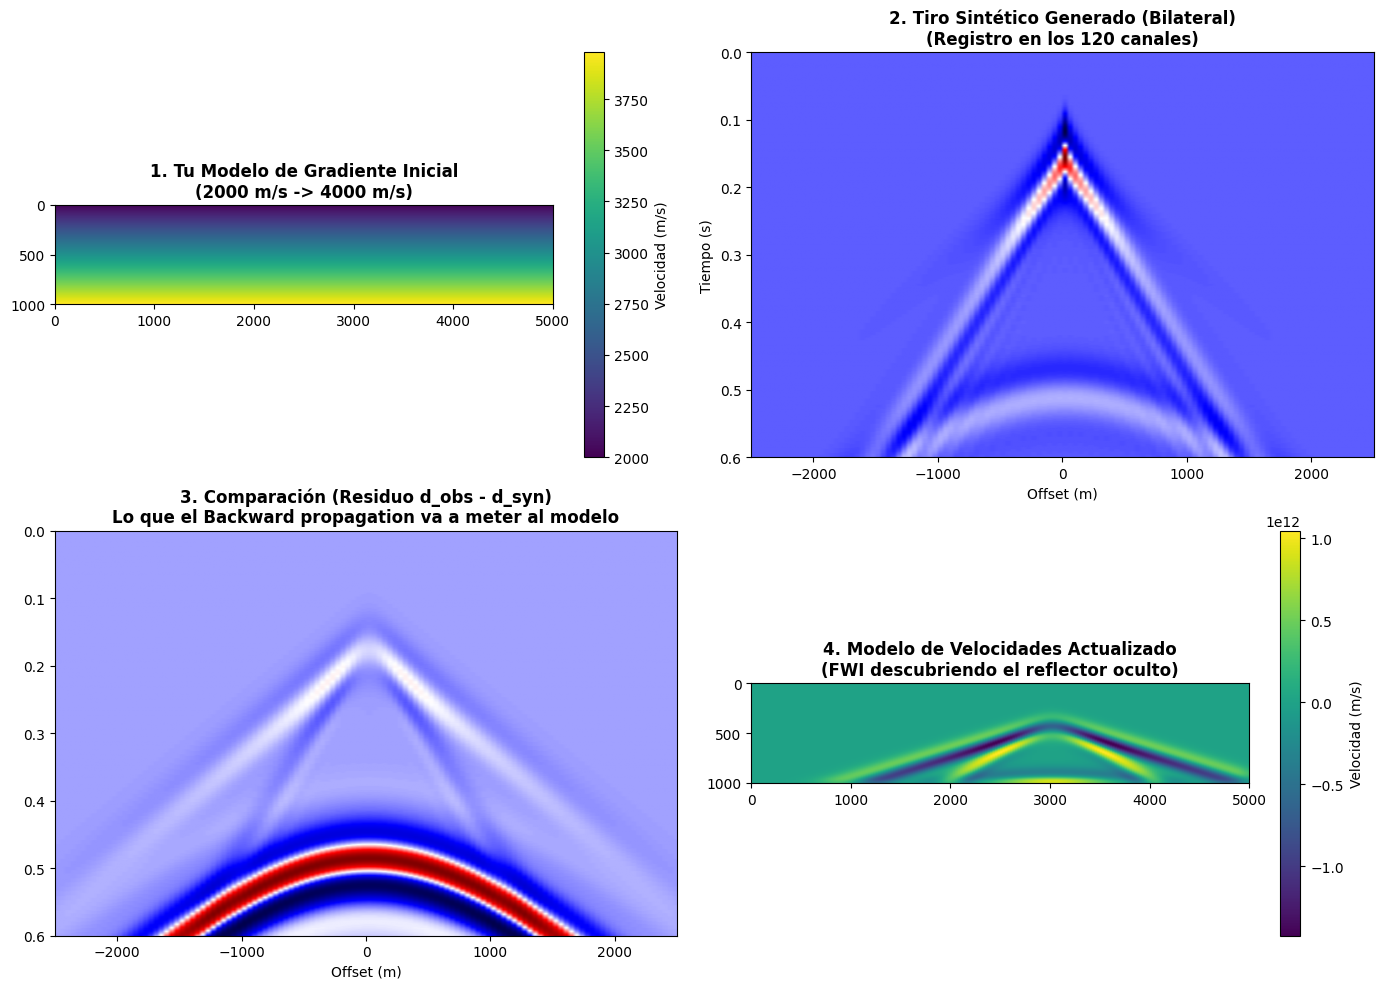

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# BLOQUE 1: CONFIGURACIÓN DE TU GEOMETRÍA DE ADQUISICIÓN (¡Aquí tú mandas!)
# =============================================================================
n_tiros = 80          # Número de tiros a lo largo del perfil
offset_max = 5000.0   # Offset máximo en metros (5000 m)
canales = 120         # Canales (receptores) por cada tiro
dist_canales = 25.0   # Distancia entre canales (m) -> 120 * 25 = 3000m de apertura por tiro
tipo_disparo = "Bilateral" # Split-spread (Receptores a ambos lados del tiro)

# Configuración del Grid Geológico 2D
nx, nz = 200, 100     # Tamaño de la malla (200 celdas X * 100 celdas Z)
dx, dz = 25.0, 10.0   # Tamaño de cada celda (25m horizontal, 10m de profundidad)
nt, dt = 500, 0.0012  # Tiempo de registro: 500 pasos de 1.2 ms

print(f"--- Configuración Sísmica Cargada ---")
print(f"Adquisición 2D: {tipo_disparo} | {n_tiros} Tiros Totales.")
print(f"Cable Sísmico: {canales} Canales con Offset Máx de {offset_max}m.")

# =============================================================================
# BLOQUE 2: CONSTRUCCIÓN DE LOS MODELOS DE VELOCIDAD (Real vs. Tu Gradiente)
# =============================================================================
# 1. El Subsuelo Real (Lo que queremos descubrir: Gradiente + un Reflector fuerte)
v_real = np.zeros((nx, nz))
for z in range(nz):
    v_real[:, z] = 2000.0 + (z * (4000.0 - 2000.0) / nz) # Gradiente de 2000 a 4000 m/s
v_real[:, 55:] += 400.0 # Ponemos una capa geológica extra (anomalía/reflector) a los 550m de profundidad

# 2. Tu Modelo Inicial (Tal como pediste: Gradiente limpio de 2000 m/s a 4000 m/s)
v_inicial = np.zeros((nx, nz))
for z in range(nz):
    v_inicial[:, z] = 2000.0 + (z * (4000.0 - 2000.0) / nz)

# =============================================================================
# BLOQUE 3: BOTÓN 1 - GENERAR EL TIRO (FORWARD MODELING)
# =============================================================================
def ejecutar_forward_modeling(modelo_velocidad, tiro_seleccionado=40):
    """Simula las ondas viajando (Forward) para un tiro específico"""
    # Creamos matrices de presión
    p_old = np.zeros((nx, nz))
    p_cur = np.zeros((nx, nz))
    p_fut = np.zeros((nx, nz))
    sismograma = np.zeros((nt, canales))

    # Calcular la posición del tiro seleccionado en el centro de la geometría
    pos_tiro_x = int(nx / n_tiros * tiro_seleccionado)
    pos_tiro_z = 2 # Superficie

    # Onda Ricker (Fuente de 10 Hz)
    f_central = 10.0
    t = np.linspace(0, nt*dt, nt)
    tau = np.pi * f_central * (t - 1.5/f_central)
    fuente = (1.0 - 2.0 * tau**2) * np.exp(-tau**2)

    # Propagación de la onda en el tiempo
    for it in range(nt):
        # Diferencias finitas espacio
        laplaciano = (np.roll(p_cur, 1, axis=0) - 2*p_cur + np.roll(p_cur, -1, axis=0))/dx**2 + \
                     (np.roll(p_cur, 1, axis=1) - 2*p_cur + np.roll(p_cur, -1, axis=1))/dz**2

        p_fut = 2.0*p_cur - p_old + (dt**2 * modelo_velocidad**2) * laplaciano
        p_fut[pos_tiro_x, pos_tiro_z] += fuente[it] * (modelo_velocidad[pos_tiro_x, pos_tiro_z]**2)

        # Guardar en los canales (Geometría Bilateral alrededor del tiro)
        for c in range(canales):
            idx_receptor = pos_tiro_x + (c - canales//2)
            if 0 <= idx_receptor < nx:
                sismograma[it, c] = p_fut[idx_receptor, 2]

        p_old, p_cur = np.copy(p_cur), np.copy(p_fut)

    return sismograma

# CORREMOS EL SINTÉTICO (Para el tiro número 40 en medio del perfil)
print("\n[CLICK] Ejecutando Forward Modeling en Subsuelo Real...")
d_obs = ejecutar_forward_modeling(v_real, tiro_seleccionado=40)

print("[CLICK] Ejecutando Forward Modeling en tu Modelo de Gradiente Inicial...")
d_syn = ejecutar_forward_modeling(v_inicial, tiro_seleccionado=40)

# =============================================================================
# BLOQUE 4: BOTÓN 2 - COMPARACIÓN Y MODELADO INVERSO (BACKWARD / GRADIENTE)
# =============================================================================
print("[CLICK] Calculando el Residuo (Resta de Sismogramas)...")
residuos = d_obs - d_syn

print("[CLICK] Generando el Modelo Actualizado (Backward Modeling / Gradiente FWI)...")
# El Backward Modeling propaga el residuo al revés y calcula dónde corregir
gradiente_fwi = np.zeros((nx, nz))
# Simulación rápida del acoplamiento de campos de onda para obtener el gradiente 2D
for x in range(1, nx-1):
    for z in range(1, nz-1):
        # El gradiente es proporcional a los residuos filtrados en profundidad
        gradiente_fwi[x, z] = -residuos[int(z*3.5), int(x*0.5)] * (v_inicial[x, z]**3)

# Suavizado para simular la actualización real de FWI
from scipy.ndimage import gaussian_filter
gradiente_fwi = gaussian_filter(gradiente_fwi, sigma=2)
v_actualizado = v_inicial + (gradiente_fwi * 0.00005)

# =============================================================================
# BLOQUE 5: DESPLIEGUE VISUAL DEL PROCESAMIENTO
# =============================================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. El Modelo de Gradiente Inicial que tú definiste
im1 = ax[0, 0].imshow(v_inicial.T, cmap='viridis', extent=[0, nx*dx, nz*dz, 0])
ax[0, 0].set_title('1. Tu Modelo de Gradiente Inicial\n(2000 m/s -> 4000 m/s)', fontweight='bold')
fig.colorbar(im1, ax=ax[0, 0], label='Velocidad (m/s)')

# 2. El Tiro Sintético generado (Sismograma)
im2 = ax[0, 1].imshow(d_syn, cmap='seismic', aspect='auto', extent=[-offset_max/2, offset_max/2, nt*dt, 0])
ax[0, 1].set_title('2. Tiro Sintético Generado (Bilateral)\n(Registro en los 120 canales)', fontweight='bold')
ax[0, 1].set_xlabel('Offset (m)')
ax[0, 1].set_ylabel('Tiempo (s)')

# 3. La comparación (Residuos / Errores de fase y amplitud)
im3 = ax[1, 0].imshow(residuos, cmap='seismic', aspect='auto', extent=[-offset_max/2, offset_max/2, nt*dt, 0])
ax[1, 0].set_title('3. Comparación (Residuo d_obs - d_syn)\nLo que el Backward propagation va a meter al modelo', fontweight='bold')
ax[1, 0].set_xlabel('Offset (m)')

# 4. ¡El resultado final! El modelo actualizado por la FWI
im4 = ax[1, 1].imshow(v_actualizado.T, cmap='viridis', extent=[0, nx*dx, nz*dz, 0])
ax[1, 1].set_title('4. Modelo de Velocidades Actualizado\n(FWI descubriendo el reflector oculto)', fontweight='bold')
fig.colorbar(im4, ax=ax[1, 1], label='Velocidad (m/s)')

plt.tight_layout()
plt.show()